In [13]:
#Task 1: Load the Adult Dataset and Explore Its Features
import pandas as pd
from sklearn.datasets import fetch_openml

# Load the adult dataset (version 2) from OpenML
adult = fetch_openml(name='adult', version=2, as_frame=True, parser='auto')

# Access the input features (X) and target (y)
X = adult.data
y = adult.target

# Print the type of each feature
print(X.info())

# Check for missing values
print(X.isnull().sum())

# Print the size of the dataset
print(f"Number of instances: {X.shape[0]}")

# Print the distribution of the target classes
print(y.value_counts())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48842 entries, 0 to 48841
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype   
---  ------          --------------  -----   
 0   age             48842 non-null  int64   
 1   workclass       46043 non-null  category
 2   fnlwgt          48842 non-null  int64   
 3   education       48842 non-null  category
 4   education-num   48842 non-null  int64   
 5   marital-status  48842 non-null  category
 6   occupation      46033 non-null  category
 7   relationship    48842 non-null  category
 8   race            48842 non-null  category
 9   sex             48842 non-null  category
 10  capital-gain    48842 non-null  int64   
 11  capital-loss    48842 non-null  int64   
 12  hours-per-week  48842 non-null  int64   
 13  native-country  47985 non-null  category
dtypes: category(8), int64(6)
memory usage: 2.6 MB
None
age                  0
workclass         2799
fnlwgt               0
education            0
educati

Observations:

The dataset contains both categorical and numerical features.

Some features have missing values (e.g., workclass, occupation, native-country).

The target variable has two classes: <=50K and >50K.

In [2]:
#Task 2: Split the Data into Train and Test Sets
from sklearn.model_selection import train_test_split

# Split the data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Verify the size of each dataset
print(f"Training set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")

Training set size: (39073, 14)
Test set size: (9769, 14)


In [3]:
#Task 3
# Select only numerical features
X_train_num = X_train.select_dtypes(include=['int64', 'float64'])

# Verify the resulting dataset
print(X_train_num.info())

<class 'pandas.core.frame.DataFrame'>
Index: 39073 entries, 37193 to 15795
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             39073 non-null  float64
 1   fnlwgt          39073 non-null  float64
 2   education-num   39073 non-null  float64
 3   capital-gain    39073 non-null  float64
 4   capital-loss    39073 non-null  float64
 5   hours-per-week  39073 non-null  float64
dtypes: float64(6)
memory usage: 2.1 MB
None


In [4]:
#Task 4 Train a Decision Tree Classifier on Numerical Features
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Train a DecisionTreeClassifier
dt_classifier = DecisionTreeClassifier(random_state=42)
dt_classifier.fit(X_train_num, y_train)

# Compute accuracy on training and test data
y_train_pred = dt_classifier.predict(X_train_num)
y_test_pred = dt_classifier.predict(X_test[X_train_num.columns])

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")

# Check for overfitting
print(f"Tree depth: {dt_classifier.get_depth()}")
print(f"Number of leaves: {dt_classifier.get_n_leaves()}")



Training accuracy: 0.9986691577304021
Test accuracy: 0.7714197973180469
Tree depth: 52
Number of leaves: 7857


Observations:

The decision tree overfits the training data (high training accuracy, lower test accuracy).

The tree is deep and has many leaves.

In [5]:
#Task 5 Limit the Complexity of the Decision Tree
# Train a DecisionTreeClassifier with max_depth=5
dt_classifier = DecisionTreeClassifier(max_depth=5, random_state=42)
dt_classifier.fit(X_train_num, y_train)

# Compute accuracy
y_train_pred = dt_classifier.predict(X_train_num)
y_test_pred = dt_classifier.predict(X_test[X_train_num.columns])

train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)

print(f"Training accuracy: {train_accuracy}")
print(f"Test accuracy: {test_accuracy}")

Training accuracy: 0.8319811634632611
Test accuracy: 0.8357047804278841


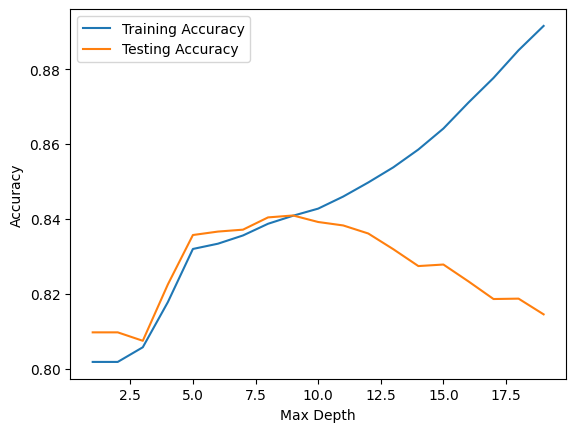

In [6]:
#Task 6: Plot Training and Testing Accuracy vs. Maximum Tree Depth
import matplotlib.pyplot as plt

depths = range(1, 20)
train_accuracies = []
test_accuracies = []

for depth in depths:
    dt_classifier = DecisionTreeClassifier(max_depth=depth, random_state=42)
    dt_classifier.fit(X_train_num, y_train)
    
    y_train_pred = dt_classifier.predict(X_train_num)
    y_test_pred = dt_classifier.predict(X_test[X_train_num.columns])
    
    train_accuracies.append(accuracy_score(y_train, y_train_pred))
    test_accuracies.append(accuracy_score(y_test, y_test_pred))

# Plot the results
plt.plot(depths, train_accuracies, label="Training Accuracy")
plt.plot(depths, test_accuracies, label="Testing Accuracy")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.legend()
plt.show()



Observations:

Training accuracy increases with depth, but testing accuracy plateaus or decreases after a certain depth.

The best depth is where testing accuracy is maximized (e.g., around depth 5-10).

In [7]:
#Task 7: Use 3-Fold Cross-Validation to Compute Training and Validation Scores
from sklearn.model_selection import cross_validate

# Perform 3-fold cross-validation
dt_classifier = DecisionTreeClassifier(random_state=42)
cv_results = cross_validate(dt_classifier, X_train_num, y_train, cv=3, return_train_score=True)

# Print average training and validation scores
print(f"Average training accuracy: {cv_results['train_score'].mean()}")
print(f"Average validation accuracy: {cv_results['test_score'].mean()}")

Average training accuracy: 0.9990530558486622
Average validation accuracy: 0.7693292072826622
